# PopOut — Estratégias Adversariais e Árvores de Decisão

**Trabalho de Inteligência Artificial**

---

Este notebook documenta a implementação e avaliação de dois paradigmas de IA aplicados ao jogo **PopOut** (variante do Connect Four):

| # | Algoritmo | Paradigma | Ficheiro |
|---|-----------|-----------|----------|
| 1 | **MCTS** — Monte Carlo Tree Search | Pesquisa em árvore em tempo real | `MCTS.py` |
| 2 | **ID3** — Árvore de Decisão | Aprendizagem supervisionada offline | `ID3.py` |

**Datasets utilizados:**
- 🌸 **Iris** — 150 amostras, 4 features contínuas, 3 classes (benchmark clássico)
- 🎲 **PopOut** — gerado por auto-jogo MCTS; 42 features (posições do tabuleiro), target = jogada

---
> **Como correr:** `Kernel → Restart & Run All`
> Garante que `iris.csv` e `popout_pairs.csv` estão em `data/`


## 1. Configuração e Importações

In [22]:
import sys, os, math, time, random, copy, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# ── Adicionar pasta do projecto ao path ──────────────────────────
import ID3 as _id3_mod
PROJECT = os.path.dirname(os.path.abspath(_id3_mod.__file__))
os.chdir(PROJECT)
if PROJECT not in sys.path:
    sys.path.insert(0, PROJECT)

# ── Módulos do projecto ──────────────────────────────────────────
from PopOut import PopOutState, ROWS, COLS, PLAYER_1, PLAYER_2, EMPTY
from MCTS   import MCTS, MCTSHeuristic, MCTSTopK, run_games, search_convergence
from ID3    import (id3, predict, predict_sample, print_tree,
                    tree_depth, count_nodes, discretize_column,
                    load_iris_data, load_popout_data,
                    train_popout_tree, train_iris_tree, evaluate_tree,
                    kfold_cross_validation, compute_metrics,
                    train_test_split_manual, save_tree, information_gain)

# ── Estilo matplotlib ────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#14141a',
    'axes.edgecolor':   '#3a3a4a',
    'axes.labelcolor':  '#e8e4db',
    'xtick.color':      '#9090aa',
    'ytick.color':      '#9090aa',
    'text.color':       '#e8e4db',
    'grid.color':       '#2a2a3a',
    'grid.alpha':       0.4,
    'legend.facecolor': '#1a1a2e',
    'legend.edgecolor': '#3a3a4a',
    'font.family':      'monospace',
})
COLORS = {
    'standard':  '#4e9cd1',
    'heuristic': '#e05c3a',
    'topk':      '#3ab87a',
    'drop':      '#4e9cd1',
    'pop':       '#e05c3a',
}

print(f"Directoria: {PROJECT}")
print(f"Python {sys.version.split()[0]}  |  Numpy {np.__version__}  |  Pandas {pd.__version__}")
print("Todos os modulos importados com sucesso.")


Directoria: c:\Users\Rui Almeida\Desktop\IA\Trb-IA\PopOut_Project
Python 3.11.9  |  Numpy 2.4.4  |  Pandas 3.0.3
Todos os modulos importados com sucesso.


## 2. O Jogo PopOut — Regras e Representação

**PopOut** é uma variante do Connect Four jogado num tabuleiro de **6 linhas × 7 colunas**.

### Movimentos disponíveis

| Tipo | Descrição | Condição |
|------|-----------|----------|
| `drop(col)` | Insere peça no topo de uma coluna | Coluna não cheia |
| `pop(col)` | Remove peça **própria** da base de uma coluna | Peça própria na base |

### Regras especiais

| Regra | Detalhe |
|-------|---------|
| **Pop simultâneo** | Se um pop criar 4-em-linha para ambos → **ganha quem fez o pop** |
| **Cascata** | Após pop, as peças acima descem — pode criar 4-em-linha para o adversário |
| **Repetição tripla** | Mesmo estado 3× → **empate** |

### Representação interna

```
Board[6][7]  →  0 = vazio  |  1 = Jogador 1  |  2 = Jogador 2
Movimento    →  ('drop', col)  ou  ('pop', col)   col em {0..6}
```


In [23]:
state = PopOutState()
print("Estado inicial (tabuleiro vazio):")
state.display_board()

s = state
moves_demo = [('drop',3),('drop',3),('drop',2),('drop',4),('drop',1)]
for m in moves_demo:
    s = s.make_move(m)

print(f"\nApos {len(moves_demo)} movimentos:")
s.display_board()
print(f"Jogador da vez : {s.get_current_player()}")
print(f"Drops validos  : {[col for t,col in s.get_valid_moves() if t=='drop']}")
print(f"Pops validos   : {[col for t,col in s.get_valid_moves() if t=='pop']}")


Estado inicial (tabuleiro vazio):

Current board:
---------------
| | | | | | | |
| | | | | | | |
| | | | | | | |
| | | | | | | |
| | | | | | | |
| | | | | | | |
---------------
Current player: X
Valid moves: [('drop', 0), ('drop', 1), ('drop', 2), ('drop', 3), ('drop', 4), ('drop', 5), ('drop', 6)]

Apos 5 movimentos:

Current board:
---------------
| | | | | | | |
| | | | | | | |
| | | | | | | |
| | | | | | | |
| | | |O| | | |
| |X|X|X|O| | |
---------------
Current player: O
Valid moves: [('drop', 0), ('drop', 1), ('drop', 2), ('drop', 3), ('drop', 4), ('drop', 5), ('drop', 6), ('pop', 4)]
Jogador da vez : 2
Drops validos  : [0, 1, 2, 3, 4, 5, 6]
Pops validos   : [4]


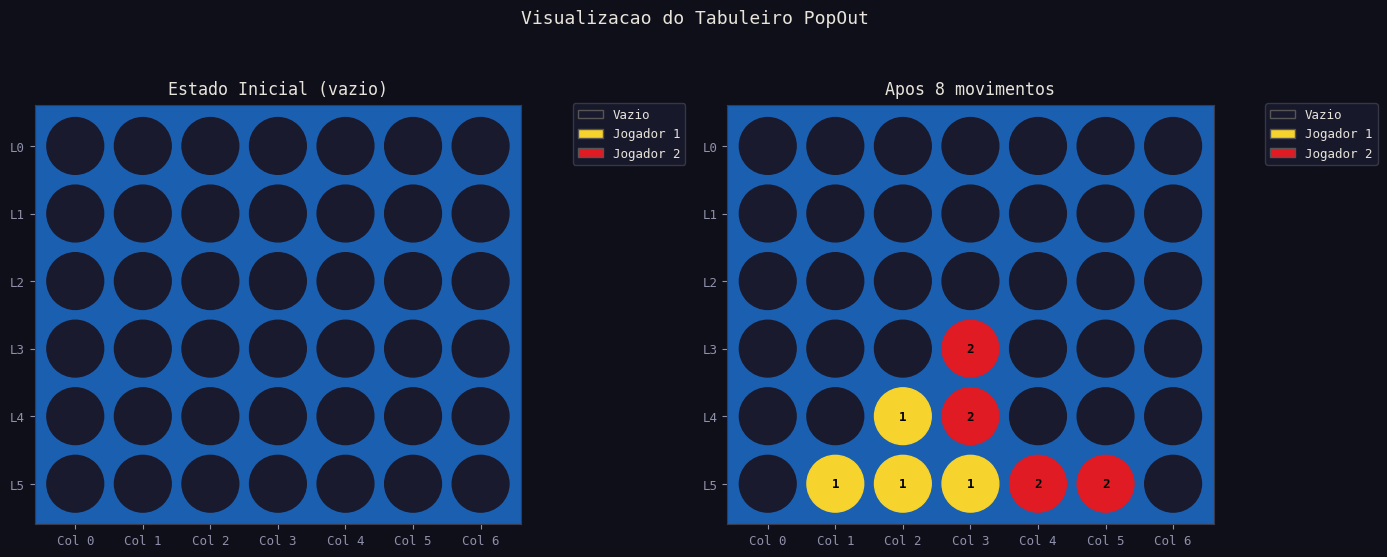

Jogador da vez : 1
Drops validos  : [0, 1, 2, 3, 4, 5, 6]
Pops validos   : [1, 2, 3]


In [3]:
def draw_board(state, title="Estado do Tabuleiro PopOut", ax=None):
    """Visualizacao grafica do tabuleiro com matplotlib."""
    board    = state.board
    own_fig  = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(7, 6))

    ax.set_facecolor('#1a5fb0')
    piece_colors = {EMPTY: '#1a1a2e', PLAYER_1: '#f6d32d', PLAYER_2: '#e01b24'}
    piece_labels = {EMPTY: 'Vazio', PLAYER_1: 'Jogador 1', PLAYER_2: 'Jogador 2'}

    for r in range(ROWS):
        for c in range(COLS):
            val = board[r][c]
            circle = plt.Circle((c, ROWS - 1 - r), 0.42,
                                 color=piece_colors[val], zorder=2)
            ax.add_patch(circle)
            if val != EMPTY:
                ax.text(c, ROWS - 1 - r, str(val),
                        ha='center', va='center', fontsize=9,
                        color='black', fontweight='bold', zorder=3)

    ax.set_xlim(-0.6, COLS - 0.4)
    ax.set_ylim(-0.6, ROWS - 0.4)
    ax.set_xticks(range(COLS))
    ax.set_xticklabels([f"Col {i}" for i in range(COLS)], fontsize=9)
    ax.set_yticks(range(ROWS))
    ax.set_yticklabels([f"L{ROWS-1-i}" for i in range(ROWS)], fontsize=9)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=12, pad=8)
    ax.grid(False)

    from matplotlib.patches import Patch
    legend_elems = [Patch(facecolor=piece_colors[k], edgecolor='#555',
                          label=piece_labels[k])
                    for k in [EMPTY, PLAYER_1, PLAYER_2]]
    ax.legend(handles=legend_elems, loc='upper right',
              bbox_to_anchor=(1.35, 1.02), fontsize=9, framealpha=0.9)

    if own_fig:
        plt.tight_layout()
        plt.show()


# ── Demonstracao visual ──────────────────────────────────────────
state_viz = PopOutState()
moves_demo_viz = [('drop',3),('drop',3),('drop',2),('drop',4),
                  ('drop',1),('drop',3),('drop',2),('drop',5)]
for m in moves_demo_viz:
    state_viz = state_viz.make_move(m)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
draw_board(PopOutState(), title="Estado Inicial (vazio)", ax=axes[0])
draw_board(state_viz, title=f"Apos {len(moves_demo_viz)} movimentos", ax=axes[1])
plt.suptitle('Visualizacao do Tabuleiro PopOut', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Jogador da vez : {state_viz.get_current_player()}")
print(f"Drops validos  : {sorted(set(col for t,col in state_viz.get_valid_moves() if t=='drop'))}")
print(f"Pops validos   : {sorted(set(col for t,col in state_viz.get_valid_moves() if t=='pop'))}")


## 3. Monte Carlo Tree Search (MCTS)

### 3.1 Visão Geral

O MCTS constrói uma árvore de pesquisa iterativamente, guiado por simulações aleatórias. Cada iteração tem **4 fases**:

```
SELECCAO (UCT)  →  EXPANSAO (1 filho)  →  SIMULACAO (rollout)  →  RETROPROPAGACAO
```

### 3.2 Fórmula UCT (Upper Confidence Bound for Trees)

$$UCT(v) = \frac{w_i}{n_i} + C \cdot \sqrt{\frac{\ln N}{n_i}}$$

- $w_i$ = vitórias acumuladas no nó filho $i$
- $n_i$ = visitas ao nó filho $i$
- $N$ = visitas ao nó pai
- $C = 1.2$ (constante de exploração desta implementação)

### 3.3 Três Variantes Implementadas

| Variante | Rollout | Expansão/iter | Vantagem principal |
|----------|---------|---------------|--------------------|
| `MCTS` Standard | Aleatório puro | 1 filho | Baseline simples e rápida |
| `MCTSHeuristic` | Heurístico: win → block → centro | 1 filho | Simulações mais informadas |
| `MCTSTopK` (K=3) | Aleatório | K filhos | Maior cobertura em largura |

### 3.4 Pré-verificação Táctica (todas as variantes)

Antes de qualquer pesquisa MCTS, verifica:
1. Existe jogada imediata vencedora? → executa-a diretamente
2. O adversário pode vencer no próximo turno? → bloqueia-a


In [4]:
state = PopOutState()

configs = [
    ('Standard',    MCTS,          {'max_simulations': 300, 'max_time': 5.0}),
    ('Heuristic',   MCTSHeuristic, {'max_simulations': 300, 'max_time': 5.0}),
    ('Top-K (K=3)', MCTSTopK,      {'max_simulations': 300, 'max_time': 5.0, 'k': 3}),
]

print(f"{'Variante':<22} {'Melhor jogada':<16} {'Win rate':>10}  {'Tempo (s)':>10}")
print("─" * 64)
for name, cls, kw in configs:
    agent = cls(**kw)
    t0 = time.time()
    move, wr = agent.search(state)
    elapsed = time.time() - t0
    print(f"{name:<22} {str(move):<16} {wr:>10.3f}  {elapsed:>10.2f}")


Variante               Melhor jogada      Win rate   Tempo (s)
────────────────────────────────────────────────────────────────
Standard               ('drop', 3)           1.000        0.01
Heuristic              ('drop', 3)           1.000        0.01
Top-K (K=3)            ('drop', 3)           1.000        0.01


### 3.5 Análise de Convergência

Avaliamos como o **win rate** da melhor jogada evolui conforme aumentamos o número de simulações.
Uma boa variante deve convergir rapidamente para um valor estável e elevado.


A calcular convergencia (aprox 1-2 min)...
  Standard         final=1.000
  Heuristic        final=1.000
  Top-K (K=3)      final=1.000

Tempo total: 0.1s


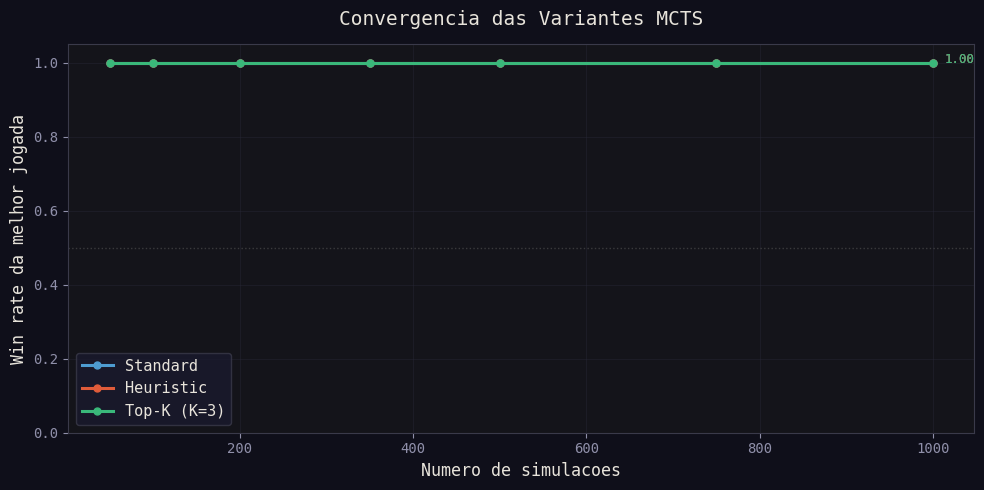


  Sims          Standard         Heuristic       Top-K (K=3)  
──────────────────────────────────────────────────────────────
    50             1.000             1.000             1.000  
   100             1.000             1.000             1.000  
   200             1.000             1.000             1.000  
   350             1.000             1.000             1.000  
   500             1.000             1.000             1.000  
   750             1.000             1.000             1.000  
  1000             1.000             1.000             1.000  


In [5]:
state = PopOutState()
checkpoints = [50, 100, 200, 350, 500, 750, 1000]

print("A calcular convergencia (aprox 1-2 min)...")
t0 = time.time()

conv_results = {}
for cls, label, kw in [
    (MCTS,          'Standard',    {}),
    (MCTSHeuristic, 'Heuristic',   {}),
    (MCTSTopK,      'Top-K (K=3)', {'k': 3}),
]:
    data = search_convergence(cls, state, checkpoints, **kw)
    conv_results[label] = data
    ys = [d[1] for d in data]
    print(f"  {label:<16} final={ys[-1]:.3f}")

print(f"\nTempo total: {time.time()-t0:.1f}s")

# ── Grafico ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
color_map = {'Standard': COLORS['standard'],
             'Heuristic': COLORS['heuristic'],
             'Top-K (K=3)': COLORS['topk']}

for label, data in conv_results.items():
    xs = [d[0] for d in data]
    ys = [d[1] for d in data]
    ax.plot(xs, ys, marker='o', markersize=5, label=label,
            color=color_map[label], linewidth=2.2)
    ax.annotate(f"{ys[-1]:.2f}", xy=(xs[-1], ys[-1]),
                xytext=(8, 0), textcoords='offset points',
                color=color_map[label], fontsize=9)

ax.set_xlabel('Numero de simulacoes', fontsize=12)
ax.set_ylabel('Win rate da melhor jogada', fontsize=12)
ax.set_title('Convergencia das Variantes MCTS', fontsize=14, pad=14)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='#555', linestyle=':', linewidth=1, alpha=0.6)
ax.grid(True)
plt.tight_layout()
plt.show()

# ── Tabela resumo ────────────────────────────────────────────────
print(f"\n{'Sims':>6}", end="  ")
for label in conv_results: print(f"{label:>16}", end="  ")
print()
print("─" * 62)
for i, n in enumerate(checkpoints):
    print(f"{n:>6}", end="  ")
    for data in conv_results.values(): print(f"{data[i][1]:>16.3f}", end="  ")
    print()


### 3.6 Comparação Head-to-Head

Cada variante joga **30 partidas como P1** contra `MCTS Standard` como P2 (30 como P2 seria ainda melhor, mas 30 já permite estimar win rates com menor variância).

> **Nota estatística:** Com 30 jogos, o desvio-padrão de uma proporção $p$ é $\sqrt{p(1-p)/30}$. Para $p=0.5$, isso é ≈ ±9% — resultados a menos de 2× esse valor não são estatisticamente conclusivos e devem ser interpretados com cautela.


A jogar 30 jogos por par (pode demorar alguns minutos)...
  Standard         0V/30D/0E  (0% ± 0%)  15s
  Heuristic        0V/30D/0E  (0% ± 0%)  23s
  Top-K (K=2)      0V/30D/0E  (0% ± 0%)  16s
  Top-K (K=3)      0V/30D/0E  (0% ± 0%)  17s

   Variante  V  D  E  Win rate  ±1σ  Tempo (s)
   Standard  0 30  0       0.0  0.0         15
  Heuristic  0 30  0       0.0  0.0         23
Top-K (K=2)  0 30  0       0.0  0.0         16
Top-K (K=3)  0 30  0       0.0  0.0         17


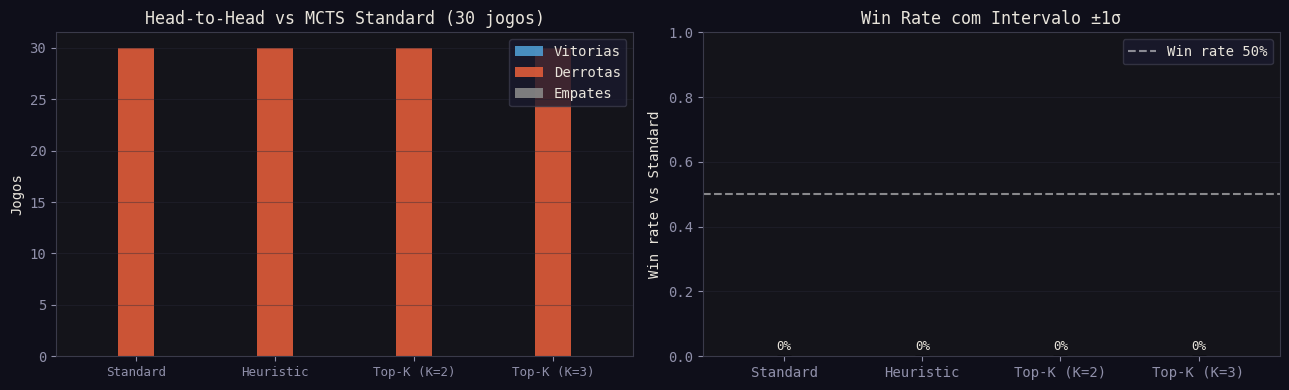

In [6]:
print("A jogar 30 jogos por par (pode demorar alguns minutos)...")
N_GAMES = 30
SIM     = 150
TLIMIT  = 0.5

baseline = MCTS(max_simulations=SIM, max_time=TLIMIT)

pairs = [
    ('Standard',    MCTS(max_simulations=SIM, max_time=TLIMIT)),
    ('Heuristic',   MCTSHeuristic(max_simulations=SIM, max_time=TLIMIT)),
    ('Top-K (K=2)', MCTSTopK(k=2, max_simulations=SIM, max_time=TLIMIT)),
    ('Top-K (K=3)', MCTSTopK(k=3, max_simulations=SIM, max_time=TLIMIT)),
]

table_rows = []
for name, agent in pairs:
    t0  = time.time()
    res = run_games(agent, baseline, n_games=N_GAMES)
    elapsed = time.time() - t0
    # Intervalo de confiança aprox. (±1 desvio-padrão)
    p   = res['p1_win_rate']
    std = (p * (1 - p) / N_GAMES) ** 0.5
    table_rows.append({
        'Variante':  name,
        'V':  res['p1_wins'],
        'D':  res['p2_wins'],
        'E':  res['draws'],
        'Win rate':  p,
        '±1σ':       round(std, 3),
        'Tempo (s)': round(elapsed),
    })
    print(f"  {name:<16} {res['p1_wins']}V/{res['p2_wins']}D/{res['draws']}E"
          f"  ({p:.0%} ± {std:.0%})  {elapsed:.0f}s")

df_hth = pd.DataFrame(table_rows)
print("\n" + "="*70)
print(df_hth.to_string(index=False))

# ── Grafico de barras agrupadas ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

names  = [r['Variante']  for r in table_rows]
wins   = [r['V']         for r in table_rows]
losses = [r['D']         for r in table_rows]
draws  = [r['E']         for r in table_rows]
wrates = [r['Win rate']  for r in table_rows]
sigmas = [r['±1σ']       for r in table_rows]

x = np.arange(len(names)); w = 0.26
axes[0].bar(x - w, wins,   w, label='Vitorias', color=COLORS['standard'],  alpha=0.9)
axes[0].bar(x,     losses, w, label='Derrotas', color=COLORS['heuristic'], alpha=0.9)
axes[0].bar(x + w, draws,  w, label='Empates',  color='#888',              alpha=0.9)
axes[0].set_xticks(x); axes[0].set_xticklabels(names, fontsize=9)
axes[0].set_ylabel('Jogos'); axes[0].set_title(f'Head-to-Head vs MCTS Standard ({N_GAMES} jogos)')
axes[0].legend(); axes[0].grid(axis='y')

axes[1].bar(names, wrates, color=[COLORS['standard'], COLORS['heuristic'],
                                  COLORS['topk'], '#a060cc'], alpha=0.85,
            yerr=sigmas, capsize=5, error_kw={'color':'#ccc', 'linewidth':1.5})
axes[1].axhline(0.5, color='#fff', linestyle='--', alpha=0.5, label='Win rate 50%')
axes[1].set_ylim(0, 1.0); axes[1].set_ylabel('Win rate vs Standard')
axes[1].set_title('Win Rate com Intervalo ±1σ'); axes[1].legend()
axes[1].grid(axis='y')
for i, (v, s) in enumerate(zip(wrates, sigmas)):
    axes[1].text(i, v + s + 0.02, f"{v:.0%}", ha='center', fontsize=9)

plt.tight_layout(); plt.show()


## 4. Dataset PopOut — Estrutura e Análise

O dataset é gerado por **auto-jogo MCTS**: dois agentes jogam entre si e cada estado do tabuleiro com a respetiva melhor jogada é guardado como uma linha CSV.

### Estrutura das colunas

| Colunas | Tipo | Descrição |
|---------|------|-----------|
| `c0` – `c41` | int {0,1,2} | Posições do tabuleiro (linha-a-linha, esq→dir) |
| `move` | str | Jogada: `"drop_3"`, `"pop_2"`, etc. |

> Para gerar mais dados: `python generate_popout_dataset.py`


Total de amostras : 38515
Features          : 42 posicoes do tabuleiro
Colunas           : ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9', 'c10', 'c11', 'c12', 'c13', 'c14', 'c15', 'c16', 'c17', 'c18', 'c19', 'c20', 'c21', 'c22', 'c23', 'c24', 'c25', 'c26', 'c27', 'c28', 'c29', 'c30', 'c31', 'c32', 'c33', 'c34', 'c35', 'c36', 'c37', 'c38', 'c39', 'c40', 'c41', 'move']

Distribuicao do target 'move':
  Drop : 20740  (53.8%)
  Pop  : 17775  (46.2%)

Top 10 jogadas mais frequentes:
move
drop_1    3323
drop_6    3208
drop_0    3205
drop_5    3182
drop_2    3031
drop_4    2934
pop_1     2838
pop_2     2682
pop_5     2665
pop_4     2641


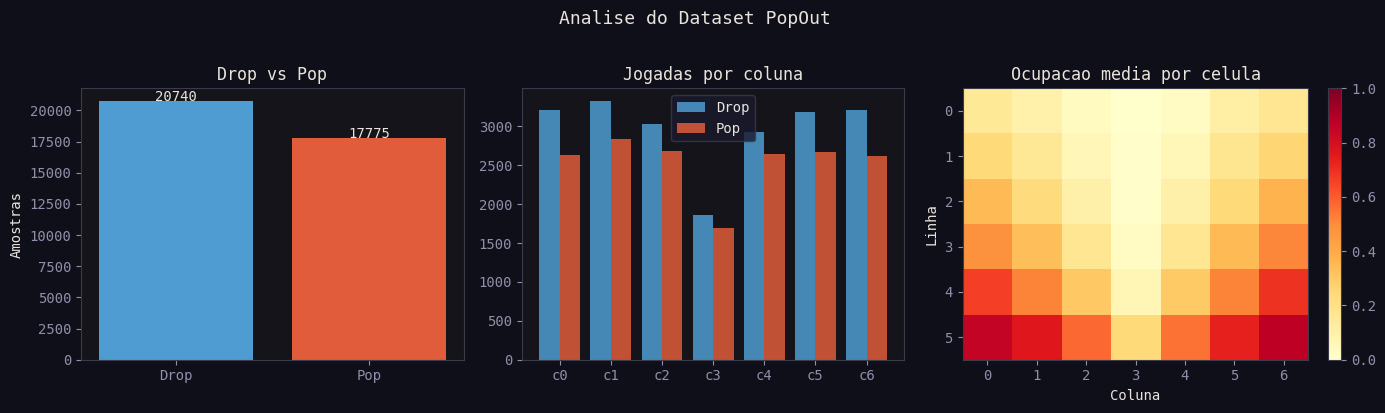

In [7]:
df = load_popout_data()

if df is None:
    print("Dataset nao encontrado. Execute generate_popout_dataset.py primeiro.")
else:
    n_total = len(df)
    board_cols = [c for c in df.columns if c.startswith('c') and c[1:].isdigit()]
    print(f"Total de amostras : {n_total}")
    print(f"Features          : {len(board_cols)} posicoes do tabuleiro")
    print(f"Colunas           : {list(df.columns)}")

    mv = df['move'].value_counts()
    drop_count = sum(v for k,v in mv.items() if 'drop' in str(k))
    pop_count  = sum(v for k,v in mv.items() if 'pop'  in str(k))
    print(f"\nDistribuicao do target 'move':")
    print(f"  Drop : {drop_count:5d}  ({drop_count/n_total*100:.1f}%)")
    print(f"  Pop  : {pop_count:5d}  ({pop_count/n_total*100:.1f}%)")
    print(f"\nTop 10 jogadas mais frequentes:")
    print(mv.head(10).to_string())

    # ── Visualizacoes ────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # 1) Tipo drop vs pop
    axes[0].bar(['Drop', 'Pop'], [drop_count, pop_count],
                color=[COLORS['drop'], COLORS['pop']])
    axes[0].set_title('Drop vs Pop'); axes[0].set_ylabel('Amostras')
    for bar, v in zip(axes[0].patches, [drop_count, pop_count]):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                     f"{v}", ha='center', fontsize=10)

    # 2) Frequencia por coluna
    col_drop = Counter()
    col_pop  = Counter()
    for m in df['move']:
        parts = str(m).split('_')
        if len(parts) == 2 and parts[1].isdigit():
            if parts[0] == 'drop': col_drop[int(parts[1])] += 1
            else:                  col_pop[int(parts[1])]  += 1
    x = np.arange(COLS)
    w = 0.4
    axes[1].bar(x - w/2, [col_drop.get(c,0) for c in range(COLS)], w,
                label='Drop', color=COLORS['drop'], alpha=0.85)
    axes[1].bar(x + w/2, [col_pop.get(c,0)  for c in range(COLS)], w,
                label='Pop',  color=COLORS['pop'],  alpha=0.85)
    axes[1].set_xticks(x); axes[1].set_xticklabels([f"c{i}" for i in range(COLS)])
    axes[1].set_title('Jogadas por coluna'); axes[1].legend()

    # 3) Ocupacao media do tabuleiro
    board_vals = df[board_cols].values.astype(float)
    occupancy  = (board_vals > 0).mean(axis=0).reshape(ROWS, COLS)
    im = axes[2].imshow(occupancy, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
    plt.colorbar(im, ax=axes[2], fraction=0.046)
    axes[2].set_title('Ocupacao media por celula')
    axes[2].set_xlabel('Coluna'); axes[2].set_ylabel('Linha')

    plt.suptitle('Analise do Dataset PopOut', fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()


## 5. Algoritmo ID3 — Fundamentos

### 5.1 O Algoritmo

O ID3 (*Iterative Dichotomiser 3*, Quinlan 1986) constrói uma árvore de decisão recursivamente, escolhendo sempre o atributo com maior **Ganho de Informação**:

$$IG(S, A) = H(S) - \sum_{v \in V(A)} \frac{|S_v|}{|S|} \cdot H(S_v)$$

onde a **Entropia** mede a impureza de um conjunto:

$$H(S) = -\sum_{c} p_c \cdot \log_2(p_c)$$

### 5.2 Critérios de Paragem

| Condição | Ação |
|----------|------|
| Todos os exemplos têm a mesma classe | Retorna folha com essa classe |
| Sem atributos disponíveis | Retorna classe majoritária |
| IG = 0 (nenhum atributo melhora) | Retorna classe majoritária |
| `depth >= max_depth` | Retorna classe majoritária |
| `len(dataset) < min_samples_split` | Retorna classe majoritária |

### 5.3 Discretização para Features Contínuas

O Iris tem 4 features contínuas. O ID3 requer features categóricas → **equal-width binning** com 4 intervalos:

| Bin | Intervalo | Label |
|-----|-----------|-------|
| 1 | [min, min+¼·range) | `muito_baixo` |
| 2 | [min+¼·range, min+½·range) | `baixo` |
| 3 | [min+½·range, min+¾·range) | `alto` |
| 4 | [min+¾·range, max] | `muito_alto` |


### 5.4 Dataset Iris — Exploração e Discretização

O dataset **Iris** (Fisher, 1936) contém **150 amostras** de flores com **4 features contínuas** (comprimento/largura da sépala e da pétala) e **3 classes equilibradas** (50 amostras cada): *Iris setosa*, *Iris versicolor* e *Iris virginica*.

Como o ID3 requer features **categóricas**, cada feature contínua é discretizada em **4 intervalos de igual largura** com os rótulos `muito_baixo`, `baixo`, `alto`, `muito_alto`.

Os histogramas abaixo mostram a distribuição original das features por classe — é visível que **`petallength`** e **`petalwidth`** separam bem *setosa* das restantes, enquanto *versicolor* e *virginica* se sobrepõem mais.


Iris raw: 150 amostras  |  Colunas: ['sepallength', 'sepalwidth', 'petallength', 'petalwidth', 'class']

Classes:
class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50

Estatisticas das features continuas:
       sepallength  sepalwidth  petallength  petalwidth
count      150.000     150.000      150.000     150.000
mean         5.843       3.054        3.759       1.199
std          0.828       0.434        1.764       0.763
min          4.300       2.000        1.000       0.100
25%          5.100       2.800        1.600       0.300
50%          5.800       3.000        4.350       1.300
75%          6.400       3.300        5.100       1.800
max          7.900       4.400        6.900       2.500

Fronteiras de discretizacao (equal-width, 4 bins):
  sepallength     [4.3,5.2)=muito_baixo  [5.2,6.1)=baixo  [6.1,7.0)=alto  [7.0,7.9)=muito_alto
  sepalwidth      [2.0,2.6)=muito_baixo  [2.6,3.2)=baixo  [3.2,3.8)=alto  [3.8,4.4)=muito_alto
  petallength     [1.0,2.5)=mu

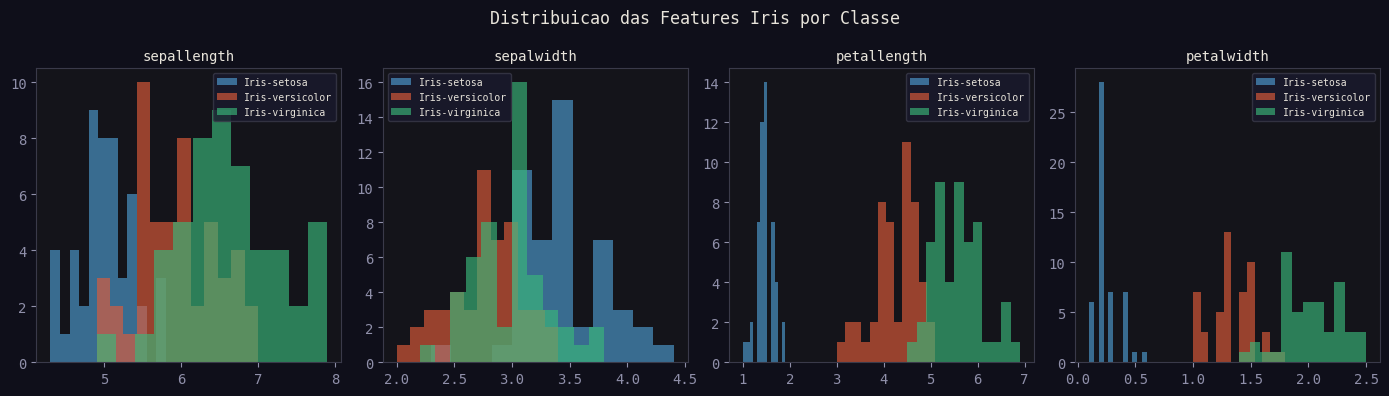

In [8]:
raw_iris = pd.read_csv('data/iris.csv')
if 'ID' in raw_iris.columns: raw_iris = raw_iris.drop(columns=['ID'])

print(f"Iris raw: {len(raw_iris)} amostras  |  Colunas: {list(raw_iris.columns)}")
print(f"\nClasses:\n{raw_iris['class'].value_counts().to_string()}")
print("\nEstatisticas das features continuas:")
print(raw_iris.describe().iloc[:, :4].round(3).to_string())

# ── Fronteiras de discretizacao ──────────────────────────────────
feat_names  = ['sepallength','sepalwidth','petallength','petalwidth']
labels_disc = ['muito_baixo','baixo','alto','muito_alto']
print("\nFronteiras de discretizacao (equal-width, 4 bins):")
for feat in feat_names:
    vals = raw_iris[feat].dropna()
    mn, mx = vals.min(), vals.max()
    edges = [mn + i*(mx-mn)/4 for i in range(5)]
    print(f"  {feat:<14}", end="")
    for i in range(4):
        print(f"  [{edges[i]:.1f},{edges[i+1]:.1f})={labels_disc[i]}", end="")
    print()

# ── Iris discretizado ─────────────────────────────────────────────
iris = load_iris_data()
print(f"\nDataset apos discretizacao (primeiras 5 linhas):")
print(iris.head(5).to_string())

# ── Visualizacao: distribuicao por classe ────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
palette = ['#4e9cd1','#e05c3a','#3ab87a']
classes = sorted(raw_iris['class'].unique())
for i, feat in enumerate(feat_names):
    for j, cls in enumerate(classes):
        subset = raw_iris[raw_iris['class']==cls][feat]
        axes[i].hist(subset, bins=12, alpha=0.65, label=cls, color=palette[j])
    axes[i].set_title(feat, fontsize=10)
    axes[i].legend(fontsize=7)
plt.suptitle('Distribuicao das Features Iris por Classe', fontsize=12)
plt.tight_layout(); plt.show()


### 5.5 Cross-Validation 5-Fold — Iris

Para estimar a capacidade de **generalização** sem desperdiçar dados em teste fixo, usamos **5-fold CV**: o dataset é dividido em 5 partes iguais; em cada ronda, 4 partes servem de treino e 1 de validação, repetindo o processo 5 vezes.

Testamos vários valores de `max_depth` para perceber o seu efeito e detetar **overfitting** (árvores muito profundas memorizam o treino mas generalizam mal). O melhor depth é selecionado automaticamente para uso posterior.


Iris — 5-fold CV por max_depth:
   max_depth   Media acc      Std  Por fold
────────────────────────────────────────────────────────────────────────
        None      0.9467   0.0452  0.967  0.867  0.967  0.933  1.000
           2      0.9467   0.0452  0.967  0.867  0.967  0.933  1.000
           3      0.9467   0.0452  0.967  0.867  0.967  0.933  1.000
           4      0.9467   0.0452  0.967  0.867  0.967  0.933  1.000
           5      0.9467   0.0452  0.967  0.867  0.967  0.933  1.000
           6      0.9467   0.0452  0.967  0.867  0.967  0.933  1.000


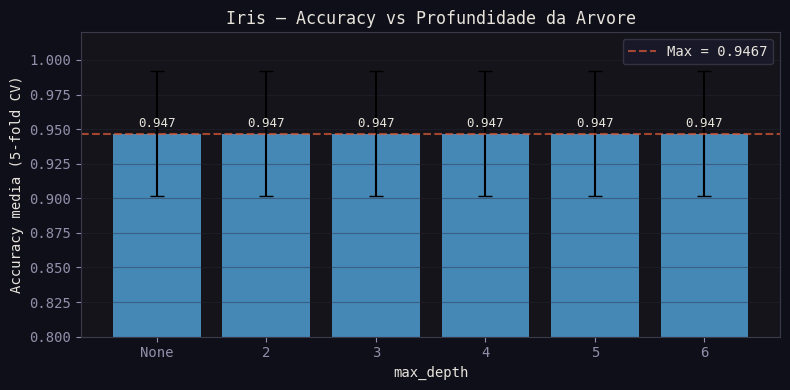

In [9]:
iris       = load_iris_data()
iris_feats = [c for c in iris.columns if c != 'class']

print("Iris — 5-fold CV por max_depth:")
print(f"{'max_depth':>12}  {'Media acc':>10}  {'Std':>7}  {'Por fold'}")
print("─" * 72)

cv_iris_results = []
accs_iris = []
for depth in [None, 2, 3, 4, 5, 6]:
    cv  = kfold_cross_validation(iris, iris_feats, 'class', k=5, max_depth=depth)
    acc = cv['mean_accuracy']
    std = np.std(cv['fold_accuracies'])
    lbl = str(depth) if depth else 'None'
    fold_str = "  ".join(f"{a:.3f}" for a in cv['fold_accuracies'])
    print(f"{lbl:>12}  {acc:>10.4f}  {std:>7.4f}  {fold_str}")
    cv_iris_results.append((lbl, acc, std, cv['fold_accuracies']))
    accs_iris.append(acc)

best_iris_acc = max(accs_iris)

# ── Grafico com barras de erro ────────────────────────────────────
labels_i = [r[0] for r in cv_iris_results]
accs_i   = [r[1] for r in cv_iris_results]
stds_i   = [r[2] for r in cv_iris_results]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels_i, accs_i, color=COLORS['standard'], alpha=0.85,
       yerr=stds_i, capsize=5, error_kw={'color':'#ccc','linewidth':1.5})
ax.axhline(best_iris_acc, color=COLORS['heuristic'], linestyle='--',
           alpha=0.7, label=f'Max = {best_iris_acc:.4f}')
for i, v in enumerate(accs_i):
    ax.text(i, v + 0.005, f"{v:.3f}", ha='center', fontsize=9)
ax.set_ylim(0.80, 1.02)
ax.set_xlabel('max_depth'); ax.set_ylabel('Accuracy media (5-fold CV)')
ax.set_title('Iris — Accuracy vs Profundidade da Arvore')
ax.legend(); ax.grid(axis='y')
plt.tight_layout(); plt.show()


### 5.6 Métricas Completas e Matriz de Confusão — Iris

A accuracy global pode ser enganosa. Por isso calculamos também **Precision**, **Recall** e **F1-score** por classe:

| Métrica | Fórmula | Quando é crítica |
|---------|---------|------------------|
| **Precision** | TP / (TP + FP) | Quando os falsos positivos são custosos |
| **Recall** | TP / (TP + FN) | Quando os falsos negativos são custosos |
| **F1** | 2·P·R / (P + R) | Balanço entre precision e recall |

A **matriz de confusão** mostra exatamente quais classes são confundidas entre si — informação que a accuracy sozinha não revela.


Training Iris tree: 120 samples, max_depth=None
Done.
Iris — Accuracy no conjunto de teste (80/20 split): 0.9667

Classe                         Precision      Recall          F1
──────────────────────────────────────────────────────────────────
Iris-setosa                       1.0000      1.0000      1.0000
Iris-versicolor                   0.9000      1.0000      0.9474
Iris-virginica                    1.0000      0.9091      0.9524

Estrutura da Arvore Iris:
  Profundidade max : 4
  Nos internos     : 5
  Folhas           : 13
  Total nos        : 18


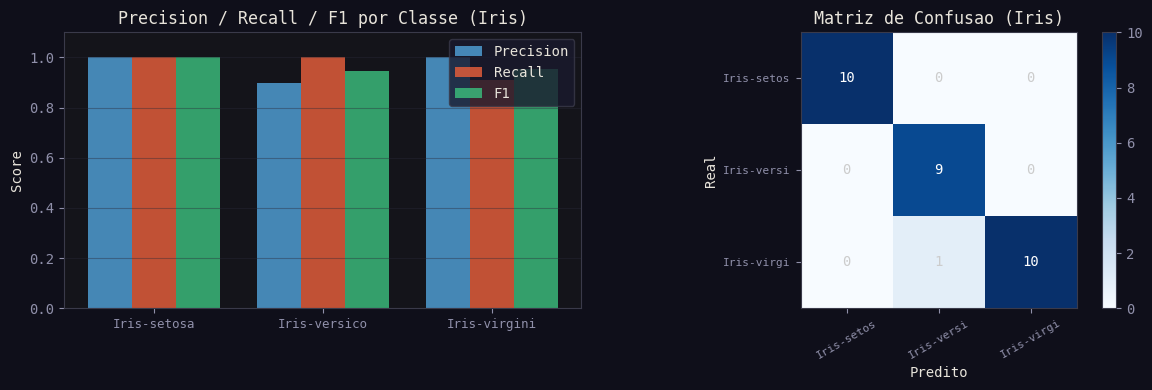

In [10]:
iris       = load_iris_data()
iris_feats = [c for c in iris.columns if c != 'class']
train_i, test_i = train_test_split_manual(iris, test_size=0.2, random_state=42)

tree_iris = train_iris_tree(train_i, max_depth=None)

preds_i  = predict(tree_iris, test_i)
actual_i = [str(v) for v in test_i['class'].tolist()]
m_i      = compute_metrics(preds_i, actual_i)

print(f"Iris — Accuracy no conjunto de teste (80/20 split): {m_i['accuracy']:.4f}\n")
print(f"{'Classe':<28}  {'Precision':>10}  {'Recall':>10}  {'F1':>10}")
print("─" * 66)
iris_classes = sorted(k for k in m_i if k != 'accuracy')
for cls in iris_classes:
    print(f"{cls:<28}  {m_i[cls]['precision']:>10.4f}"
          f"  {m_i[cls]['recall']:>10.4f}  {m_i[cls]['f1']:>10.4f}")

leaves_i, internal_i = count_nodes(tree_iris)
print(f"\nEstrutura da Arvore Iris:")
print(f"  Profundidade max : {tree_depth(tree_iris)}")
print(f"  Nos internos     : {internal_i}")
print(f"  Folhas           : {leaves_i}")
print(f"  Total nos        : {leaves_i + internal_i}")

# ── Graficos metricas + matriz de confusao ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x      = np.arange(len(iris_classes))
w      = 0.26
colors3 = [COLORS['standard'], COLORS['heuristic'], COLORS['topk']]
for idx_m, (metric, label) in enumerate([('precision','Precision'),
                                          ('recall','Recall'),
                                          ('f1','F1')]):
    vals = [m_i[c][metric] for c in iris_classes]
    axes[0].bar(x + (idx_m-1)*w, vals, w, label=label,
                color=colors3[idx_m], alpha=0.85)
short_lbl = [c.split('.')[-1][:12] for c in iris_classes]
axes[0].set_xticks(x); axes[0].set_xticklabels(short_lbl, fontsize=9)
axes[0].set_ylim(0, 1.1); axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 por Classe (Iris)')
axes[0].legend(); axes[0].grid(axis='y')

cls_list = sorted(set(actual_i))
n_cls = len(cls_list)
cm = np.zeros((n_cls, n_cls), dtype=int)
idx_map = {c: i for i, c in enumerate(cls_list)}
for p, a in zip(preds_i, actual_i):
    cm[idx_map[a]][idx_map[p]] += 1
im = axes[1].imshow(cm, cmap='Blues')
plt.colorbar(im, ax=axes[1])
axes[1].set_xticks(range(n_cls)); axes[1].set_yticks(range(n_cls))
snames = [c.split('.')[-1][:10] for c in cls_list]
axes[1].set_xticklabels(snames, rotation=30, fontsize=8)
axes[1].set_yticklabels(snames, fontsize=8)
axes[1].set_xlabel('Predito'); axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de Confusao (Iris)')
for i in range(n_cls):
    for j in range(n_cls):
        axes[1].text(j, i, str(cm[i,j]), ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else '#ccc')
plt.tight_layout(); plt.show()


### 5.7 Visualização da Árvore Iris (primeiros 3 níveis)

A árvore completa tem demasiados nós para visualizar integralmente; mostramos os **3 primeiros níveis** para perceber a lógica de decisão.

O **nó raiz** usa a feature com maior Information Gain — tipicamente **`petallength`** — que separa *setosa* das restantes com quase perfeição. Os níveis seguintes refinam a distinção entre *versicolor* e *virginica* usando `petalwidth` e `sepallength`.


In [11]:
def trim_tree(t, d=0, max_d=3):
    if not isinstance(t, dict) or d >= max_d:
        return t if not isinstance(t, dict) else '[...]'
    attr = next(iter(t))
    return {attr: {v: trim_tree(s, d+1, max_d) for v, s in t[attr].items()
                   if v != '_majority'}}

iris       = load_iris_data()
iris_feats = [c for c in iris.columns if c != 'class']
train_i, _ = train_test_split_manual(iris, test_size=0.2, random_state=42)
tree_iris  = train_iris_tree(train_i, max_depth=None)

print("Arvore de Decisao Iris (profundidade max = 3):")
print("=" * 58)
print_tree(trim_tree(tree_iris, max_d=3))
print()
print("Nota: o primeiro split usa 'petallength' — a feature com maior IG,")
print("a mais discriminativa para separar as 3 classes.")


Training Iris tree: 120 samples, max_depth=None
Done.
Arvore de Decisao Iris (profundidade max = 3):
petalwidth
├── muito_baixo:
    → Iris-setosa
├── alto:
    petallength
    ├── alto:
        sepallength
        ├── alto:
            → [...]
        ├── baixo:
            → [...]
        ├── muito_alto:
            → Iris-versicolor
        └── muito_baixo:
            → Iris-virginica
    ├── muito_alto:
        → Iris-virginica
    └── baixo:
        → Iris-versicolor
├── muito_alto:
    → Iris-virginica
└── baixo:
    → Iris-versicolor

Nota: o primeiro split usa 'petallength' — a feature com maior IG,
a mais discriminativa para separar as 3 classes.


### 5.8 Curva de Aprendizagem — Iris

A **curva de aprendizagem** mostra como a accuracy no conjunto de treino e de validação evolui conforme aumentamos o número de amostras de treino.

- Se a **accuracy de treino** for muito superior à de **validação**, há **overfitting**.
- Se ambas convergirem para um valor baixo, há **underfitting** (modelo demasiado simples).
- O ID3 sem restrição de profundidade tende a fazer overfitting em conjuntos pequenos — é o que esperamos ver nas primeiras amostras.


Curva de aprendizagem Iris:
N treino   Train acc     Val acc
───────────────────────────────────
      12      1.0000      0.8333
      24      0.9583      0.9667
      36      0.9444      0.9667
      48      0.9375      0.9667
      60      0.9500      0.9667
      72      0.9444      0.9667
      84      0.9405      0.9667
      96      0.9479      0.9667
     108      0.9537      0.9667
     120      0.9500      0.9667


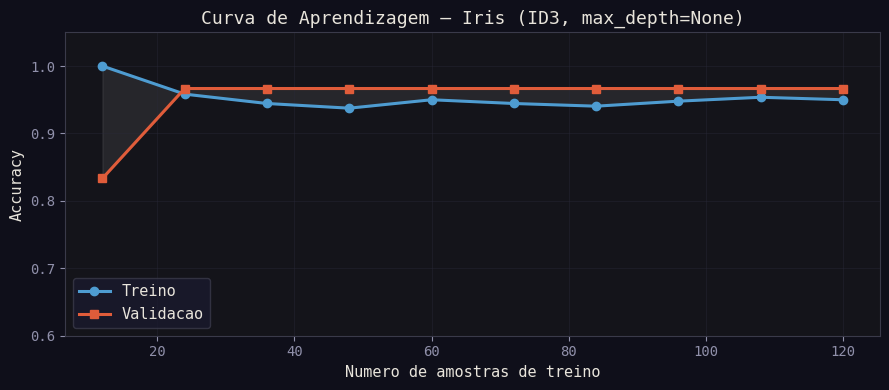


Gap treino-validacao:  inicio = 0.1667  |  fim = -0.0167
Interpretacao: gap pequeno no final => boa generalizacao com os dados disponiveis.


In [12]:
iris       = load_iris_data()
iris_feats = [c for c in iris.columns if c != 'class']

# Separar teste fixo (20%) e treino progressivo (do restante)
np.random.seed(42)
all_idx = list(iris.index)
np.random.shuffle(all_idx)
n_test_lc   = int(len(all_idx) * 0.2)
test_idx_lc = all_idx[:n_test_lc]
pool_idx    = all_idx[n_test_lc:]

train_fractions = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]
lc_train_accs = []
lc_val_accs   = []
lc_sizes      = []

print("Curva de aprendizagem Iris:")
print(f"{'N treino':>8}  {'Train acc':>10}  {'Val acc':>10}")
print("─" * 35)
for frac in train_fractions:
    n_train = max(10, int(len(pool_idx) * frac))
    train_idx = pool_idx[:n_train]
    train_df  = iris.loc[train_idx]
    test_df   = iris.loc[test_idx_lc]

    tree_lc = id3(train_df, iris_feats, 'class', max_depth=None)
    t_acc = evaluate_tree(tree_lc, train_df, 'class')
    v_acc = evaluate_tree(tree_lc, test_df,  'class')

    lc_sizes.append(n_train)
    lc_train_accs.append(t_acc)
    lc_val_accs.append(v_acc)
    print(f"{n_train:>8}  {t_acc:>10.4f}  {v_acc:>10.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lc_sizes, lc_train_accs, 'o-', color=COLORS['standard'],  label='Treino',    linewidth=2.2, markersize=6)
ax.plot(lc_sizes, lc_val_accs,   's-', color=COLORS['heuristic'], label='Validacao', linewidth=2.2, markersize=6)
ax.fill_between(lc_sizes, lc_train_accs, lc_val_accs, alpha=0.12, color='#aaa')
ax.set_xlabel('Numero de amostras de treino', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Curva de Aprendizagem — Iris (ID3, max_depth=None)', fontsize=13)
ax.set_ylim(0.60, 1.05)
ax.legend(fontsize=11); ax.grid(True)
plt.tight_layout(); plt.show()

gap_first = lc_train_accs[0] - lc_val_accs[0]
gap_last  = lc_train_accs[-1] - lc_val_accs[-1]
print(f"\nGap treino-validacao:  inicio = {gap_first:.4f}  |  fim = {gap_last:.4f}")
print("Interpretacao: gap pequeno no final => boa generalizacao com os dados disponiveis.")


## 6. ID3 — Dataset PopOut

### Desafios específicos

| Desafio | Detalhes |
|---------|----------|
| **42 features** | Uma por cada célula; valores {0, 1, 2} |
| **Classes desbalanceadas** | ~90–95% drop, ~5–10% pop |
| **Target multi-valor** | `"drop_col"` ou `"pop_col"` — muitas classes possíveis |
| **Features irrelevantes** | Muitas posições são 0 (vazias) num dado estado |

### Estratégia de avaliação

Como a classe *pop* é rara, a **accuracy sozinha é enganosa** — um classificador que diz sempre "drop" tem ~90%+ de accuracy. Usamos também **Precision, Recall e F1** por classe.


### 6.1 Carregamento do Dataset e Balanceamento de Classes

O dataset gerado pelo MCTS tem um desequilíbrio significativo entre as 14 classes de jogadas:
- **`drop_1`** pode ter ~10× mais amostras que **`pop_3`**
- Sem balanceamento, a árvore ID3 ignora as classes raras e prevê apenas as mais comuns → accuracy enganosa

**Estratégia aplicada: undersampling** — cada classe é truncada para o tamanho da classe mais pequena. Perde-se dados, mas elimina-se o viés e a árvore aprende todas as classes igualmente.

> **Dica:** Para resultados muito melhores, corre `python generate_popout_dataset_strong.py` antes de abrir o notebook. O dataset *strong* tem 500 jogos com MCTS 1000 sims e é carregado automaticamente se existir.


Dataset strong nao encontrado. A usar original: popout_pairs.csv

Dataset  : Original (500 sims, 200 jogos)
Amostras : 38515  |  Classes: 14
Min      : 1693 (pop_3)
Max      : 3323 (drop_1)
Ratio    : 2.0x

Sem undersampling: 38515 amostras mantidas (ratio 2.0x e aceitavel)


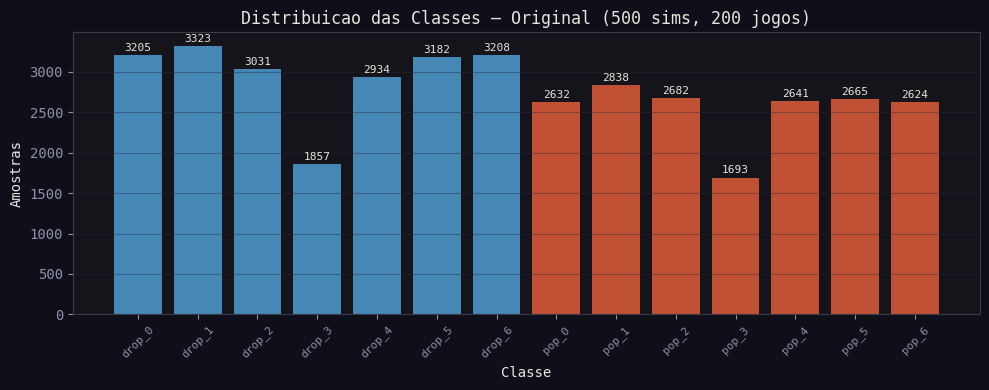

In [13]:

# ── Detectar e carregar o melhor dataset disponível ─────────────────────────
STRONG_CSV = os.path.join(PROJECT, 'data', 'popout_pairs_strong.csv')
ORIG_CSV   = os.path.join(PROJECT, 'data', 'popout_pairs.csv')

if os.path.exists(STRONG_CSV):
    print(f"Dataset STRONG encontrado: popout_pairs_strong.csv")
    df = load_popout_data(STRONG_CSV)
    dataset_label = 'Strong (1000 sims, 500 jogos)'
else:
    print("Dataset strong nao encontrado. A usar original: popout_pairs.csv")
    df = load_popout_data()
    dataset_label = 'Original (500 sims, 200 jogos)'

if df is None:
    print("ERRO: Nenhum dataset encontrado. Execute generate_popout_dataset.py primeiro.")
    df_str = None
    feats_p = None
else:
    feats_p = [f'c{i}' for i in range(42)]
    df['move'] = df['move'].astype(str)

    counts_orig = df['move'].value_counts().sort_index()
    print(f"\nDataset  : {dataset_label}")
    print(f"Amostras : {len(df)}  |  Classes: {df['move'].nunique()}")
    print(f"Min      : {counts_orig.min()} ({counts_orig.idxmin()})")
    print(f"Max      : {counts_orig.max()} ({counts_orig.idxmax()})")
    print(f"Ratio    : {counts_orig.max() / counts_orig.min():.1f}x")

    # Ratio 2.0x e aceitavel — usar dados originais sem undersampling
    df_str = df.copy()
    print(f"\nSem undersampling: {len(df_str)} amostras mantidas "
          f"(ratio {counts_orig.max() / counts_orig.min():.1f}x e aceitavel)")

    # ── Gráfico distribuição original ────────────────────────────────────────
    fig, ax1 = plt.subplots(figsize=(10, 4))
    pal = [COLORS['drop'] if 'drop' in m else COLORS['pop']
           for m in counts_orig.index]

    ax1.bar(counts_orig.index, counts_orig.values, color=pal, alpha=0.85)
    ax1.set_title(f'Distribuicao das Classes — {dataset_label}')
    ax1.set_xlabel('Classe'); ax1.set_ylabel('Amostras')
    ax1.tick_params(axis='x', rotation=45, labelsize=8)
    ax1.grid(axis='y')
    for i, v in enumerate(counts_orig.values):
        ax1.text(i, v + 50, str(v), ha='center', fontsize=8)

    plt.tight_layout(); plt.show()


PopOut — 5-fold CV por max_depth (dados balanceados):
   max_depth   Media acc      Std  Por fold
────────────────────────────────────────────────────────────────────────
        None      0.1025   0.0010  0.102  0.102  0.102  0.104  0.103
           3      0.1411   0.0032  0.140  0.145  0.136  0.139  0.144
           5      0.1386   0.0015  0.137  0.140  0.137  0.141  0.139
           7      0.1212   0.0027  0.120  0.122  0.119  0.118  0.126
          10      0.1058   0.0016  0.103  0.106  0.108  0.105  0.106
          15      0.1023   0.0012  0.103  0.101  0.101  0.104  0.103

>>> Melhor max_depth (finito): 3  (acc=0.1411) <<<


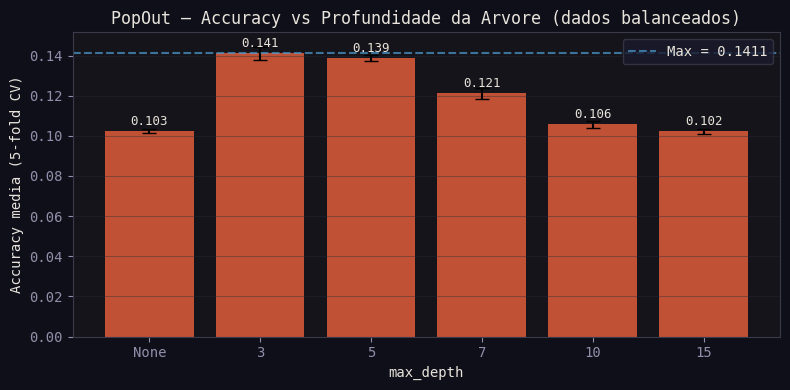

In [14]:
if df_str is None:
    print("ERRO: Execute a celula de carregamento/balanceamento acima primeiro!")
    best_depth_popout = 10  # valor de fallback
else:
    print("PopOut — 5-fold CV por max_depth (dados balanceados):")
    print(f"{'max_depth':>12}  {'Media acc':>10}  {'Std':>7}  {'Por fold'}")
    print("─" * 72)

    cv_popout = []
    accs_p    = []
    for depth in [None, 3, 5, 7, 10, 15]:
        cv  = kfold_cross_validation(df_str, feats_p, 'move', k=5, max_depth=depth)
        acc = cv['mean_accuracy']
        std = np.std(cv['fold_accuracies'])
        lbl = str(depth) if depth else 'None'
        fold_str = "  ".join(f"{a:.3f}" for a in cv['fold_accuracies'])
        print(f"{lbl:>12}  {acc:>10.4f}  {std:>7.4f}  {fold_str}")
        cv_popout.append((lbl, acc, std))
        accs_p.append((depth, acc))

    # Seleccao automatica: depth com maior accuracy media (preferir finito sobre None)
    finite_results = [(d, a) for d, a in accs_p if d is not None]
    best_depth_popout = max(finite_results, key=lambda x: x[1])[0]
    best_acc_popout   = max(a for _, a in accs_p)
    print(f"\n>>> Melhor max_depth (finito): {best_depth_popout}  (acc={best_acc_popout:.4f}) <<<")

    labels_p = [r[0] for r in cv_popout]
    stds_p   = [r[2] for r in cv_popout]
    accs_plot= [r[1] for r in cv_popout]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(labels_p, accs_plot, color=COLORS['heuristic'], alpha=0.85,
           yerr=stds_p, capsize=5, error_kw={'color':'#ccc','linewidth':1.5})
    ax.axhline(best_acc_popout, color=COLORS['standard'], linestyle='--',
               alpha=0.7, label=f'Max = {best_acc_popout:.4f}')
    for i, v in enumerate(accs_plot):
        ax.text(i, v + 0.003, f"{v:.3f}", ha='center', fontsize=9)
    ax.set_xlabel('max_depth'); ax.set_ylabel('Accuracy media (5-fold CV)')
    ax.set_title('PopOut — Accuracy vs Profundidade da Arvore (dados balanceados)')
    ax.legend(); ax.grid(axis='y')
    plt.tight_layout(); plt.show()


In [15]:
if df_str is not None:
    # Treino com dados balanceados (df_str) e best_depth derivado da CV
    train_p, test_p = train_test_split_manual(df_str, test_size=0.2, random_state=42)
    tree_p = train_popout_tree(train_p, max_depth=best_depth_popout, min_samples_split=5)

    preds_p  = predict(tree_p, test_p)
    actual_p = [str(v) for v in test_p['move'].tolist()]
    m_p      = compute_metrics(preds_p, actual_p)

    print(f"PopOut — Accuracy (test, max_depth={best_depth_popout}): {m_p['accuracy']:.4f}\n")

    drop_classes = sorted(k for k in m_p if k != 'accuracy' and 'drop' in k)
    pop_classes  = sorted(k for k in m_p if k != 'accuracy' and 'pop'  in k)

    print(f"{'Classe':<14}  {'Precision':>10}  {'Recall':>10}  {'F1':>10}  {'Suporte':>8}")
    print("─" * 60)
    for cls in drop_classes + pop_classes:
        sup = actual_p.count(cls)
        print(f"{cls:<14}  {m_p[cls]['precision']:>10.4f}"
              f"  {m_p[cls]['recall']:>10.4f}  {m_p[cls]['f1']:>10.4f}  {sup:>8}")

    leaves_p, internal_p = count_nodes(tree_p)
    print(f"\nEstrutura (max_depth={best_depth_popout}):")
    print(f"  Profundidade : {tree_depth(tree_p)}")
    print(f"  Nos internos : {internal_p}")
    print(f"  Folhas       : {leaves_p}")
    save_tree(tree_p)
    print("\nArvore guardada em data/popout_tree.json")
else:
    tree_p = None
    print("Execute a celula de carregamento/balanceamento (celula 28) primeiro.")


Training PopOut tree: 30812 samples, max_depth=3
Done.
PopOut — Accuracy (test, max_depth=3): 0.1427

Classe           Precision      Recall          F1   Suporte
────────────────────────────────────────────────────────────
drop_0              0.0000      0.0000      0.0000       640
drop_1              0.0000      0.0000      0.0000       673
drop_2              0.0000      0.0000      0.0000       591
drop_3              0.0000      0.0000      0.0000       377
drop_4              0.0000      0.0000      0.0000       596
drop_5              0.1163      0.1659      0.1367       651
drop_6              0.0000      0.0000      0.0000       621
pop_0               0.0000      0.0000      0.0000       550
pop_1               0.0000      0.0000      0.0000       561
pop_2               0.1427      0.5393      0.2257       534
pop_3               0.1804      1.0000      0.3056       329
pop_4               0.1276      0.7305      0.2172       512
pop_5               0.0000      0.0000      

### 6.1 Information Gain por Posição do Tabuleiro

Nem todas as 42 células do tabuleiro são igualmente informativas. O **Information Gain** mede quanto cada posição reduz a incerteza sobre a jogada ideal:

$$IG(S, A) = H(S) - \sum_{v} \frac{|S_v|}{|S|} \cdot H(S_v)$$

A hipótese é que as **posições centrais e das linhas inferiores** tenham maior IG — controlam mais sequências possíveis de 4 em linha. O mapa de calor abaixo confirma (ou refuta) esta hipótese com os dados reais do auto-jogo MCTS.


Top 10 features por Information Gain:
  c38 (linha 5, col 3):  IG = 0.097750
  c39 (linha 5, col 4):  IG = 0.062349
  c37 (linha 5, col 2):  IG = 0.060096
  c40 (linha 5, col 5):  IG = 0.033352
  c36 (linha 5, col 1):  IG = 0.032262
  c6 (linha 0, col 6):  IG = 0.024865
  c0 (linha 0, col 0):  IG = 0.023284
  c35 (linha 5, col 0):  IG = 0.018112
  c5 (linha 0, col 5):  IG = 0.016833
  c31 (linha 4, col 3):  IG = 0.016628


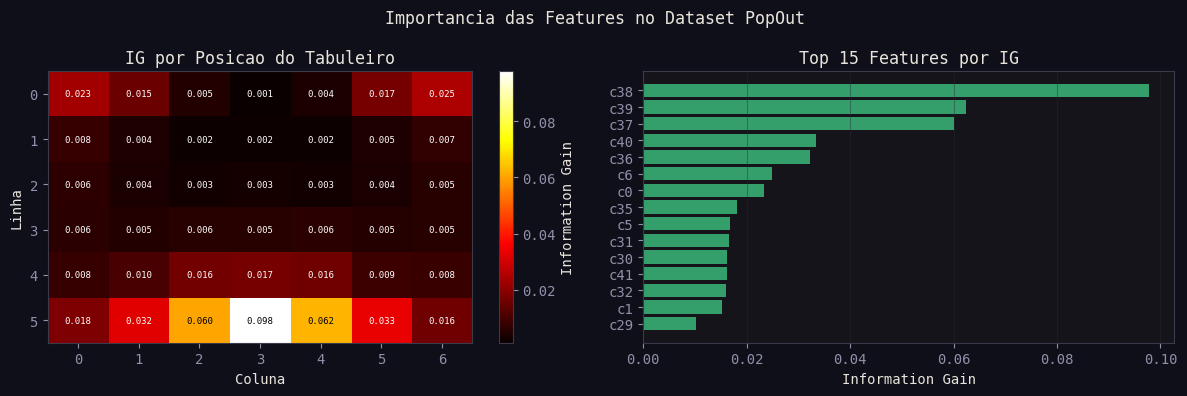


Observacao: posicoes centrais e inferiores tendem a ter maior IG,
pois influenciam mais directamente o resultado do jogo.


In [16]:
if df_str is not None:
    ig_vals = {}
    for feat in [f'c{i}' for i in range(42)]:
        ig_vals[feat] = information_gain(df_str, feat, 'move')

    ig_series = pd.Series(ig_vals).sort_values(ascending=False)

    print("Top 10 features por Information Gain:")
    for feat, ig in ig_series.head(10).items():
        cell_idx = int(feat[1:])
        row_i = cell_idx // COLS
        col_i = cell_idx % COLS
        print(f"  {feat} (linha {row_i}, col {col_i}):  IG = {ig:.6f}")

    ig_board = np.array([ig_vals.get(f'c{i}', 0) for i in range(42)]).reshape(ROWS, COLS)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    im = axes[0].imshow(ig_board, cmap='hot', aspect='auto')
    plt.colorbar(im, ax=axes[0], label='Information Gain')
    axes[0].set_title('IG por Posicao do Tabuleiro')
    axes[0].set_xlabel('Coluna'); axes[0].set_ylabel('Linha')
    for i in range(ROWS):
        for j in range(COLS):
            axes[0].text(j, i, f"{ig_board[i,j]:.3f}", ha='center', va='center',
                        fontsize=6.5,
                        color='black' if ig_board[i,j] > ig_board.max()*0.6 else 'white')

    top15 = ig_series.head(15)
    axes[1].barh(top15.index[::-1], top15.values[::-1], color=COLORS['topk'], alpha=0.85)
    axes[1].set_xlabel('Information Gain')
    axes[1].set_title('Top 15 Features por IG')
    axes[1].grid(axis='x')

    plt.suptitle('Importancia das Features no Dataset PopOut', fontsize=12)
    plt.tight_layout(); plt.show()
    print("\nObservacao: posicoes centrais e inferiores tendem a ter maior IG,")
    print("pois influenciam mais directamente o resultado do jogo.")
else:
    print("Execute a celula de carregamento/balanceamento (celula 28) primeiro.")


### 6.2 Visualização da Árvore PopOut (primeiros 3 níveis)

A árvore PopOut é muito maior que a do Iris (42 features, dezenas de classes possíveis). Mostramos apenas os **3 primeiros níveis** para perceber quais as posições do tabuleiro que o ID3 considera mais determinantes.

O formato `cN [lR, cC]` indica a célula N do tabuleiro, correspondente à **linha R** e **coluna C** (0-indexed, topo=0). Comparar com o mapa de IG da secção anterior para verificar coerência.


In [17]:
if df is not None and tree_p is not None:
    def trim_tree_popout(t, d=0, max_d=3):
        if not isinstance(t, dict) or d >= max_d:
            return str(t)
        attr = next(iter(t))
        col_num = attr.replace('c','')
        if col_num.isdigit():
            c_idx = int(col_num)
            label = f"{attr} [l{c_idx//COLS},c{c_idx%COLS}]"
        else:
            label = attr
        return {label: {str(v): trim_tree_popout(s, d+1, max_d)
                        for v, s in t[attr].items() if v != '_majority'}}

    print("Arvore PopOut (3 primeiros niveis):")
    print("=" * 58)
    print_tree(trim_tree_popout(tree_p, max_d=3))
else:
    print("Arvore nao disponivel — execute as celulas anteriores com o dataset PopOut.")


Arvore PopOut (3 primeiros niveis):
c38 [l5,c3]
├── 0:
    c39 [l5,c4]
    ├── 0:
        c37 [l5,c2]
        ├── 1:
            → pop_2
        ├── 0:
            → drop_5
        └── 2:
            → pop_2
    ├── 1:
        c37 [l5,c2]
        ├── 1:
            → pop_2
        ├── 0:
            → pop_4
        └── 2:
            → pop_4
    └── 2:
        c37 [l5,c2]
        ├── 1:
            → pop_4
        ├── 2:
            → pop_4
        └── 0:
            → pop_4
├── 2:
    c37 [l5,c2]
    ├── 2:
        c39 [l5,c4]
        ├── 0:
            → pop_3
        ├── 1:
            → pop_3
        └── 2:
            → pop_3
    ├── 0:
        c39 [l5,c4]
        ├── 0:
            → pop_3
        ├── 1:
            → pop_3
        └── 2:
            → pop_3
    └── 1:
        c39 [l5,c4]
        ├── 1:
            → pop_3
        ├── 0:
            → pop_3
        └── 2:
            → pop_3
└── 1:
    c37 [l5,c2]
    ├── 0:
        c39 [l5,c4]
        ├── 0:
            → pop_3


### 6.3 Curva de Aprendizagem — PopOut

Com **classes muito desbalanceadas** (≈90% drop), a curva de aprendizagem é especialmente importante: mostra se a tree consegue aprender algo além de "diz sempre drop" conforme cresce o dataset.

Se a accuracy de validação estabilizar num valor alto mas o **Recall da classe pop** for próximo de zero, temos um classificador maioritário disfarçado — e o F1 médio revelará isso.


Curva de aprendizagem PopOut (best_depth=3):
N treino   Train acc     Val acc    F1 pop (medio)
────────────────────────────────────────────────────
    1540      0.1623      0.1007            0.1235
    3081      0.1457      0.1267            0.1082
    6162      0.1459      0.1340            0.1126
    9243      0.1435      0.1384            0.1107
   12324      0.1431      0.1367            0.1031
   18487      0.1426      0.1402            0.1059
   24649      0.1429      0.1388            0.1057
   30812      0.1423      0.1427            0.1069


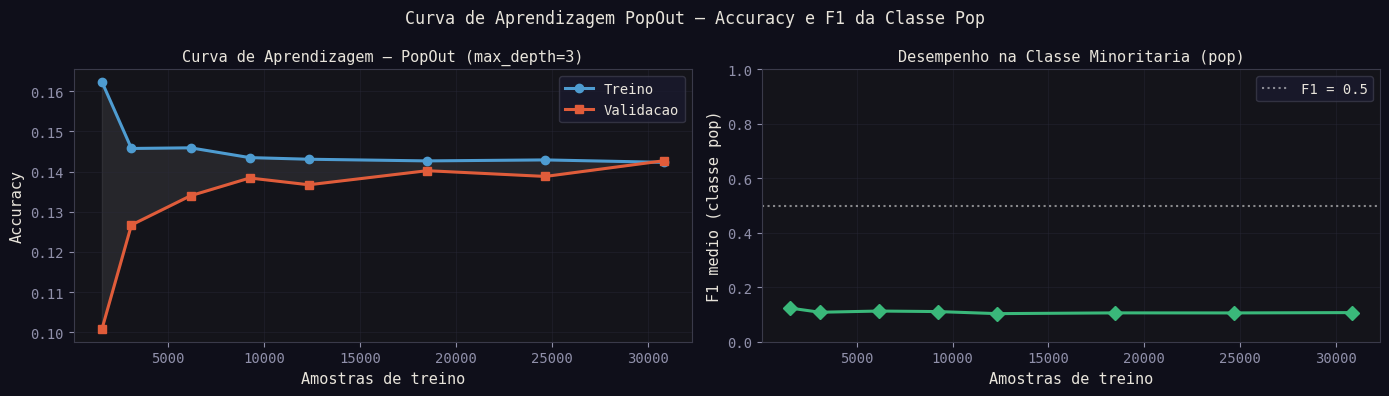

In [18]:
if df_str is not None:
    feats_p_lc = [f'c{i}' for i in range(42)]
    df_lc      = df_str.copy()  # usa dados balanceados

    np.random.seed(42)
    all_idx_p = list(df_lc.index)
    np.random.shuffle(all_idx_p)
    n_test_p   = int(len(all_idx_p) * 0.2)
    test_idx_p = all_idx_p[:n_test_p]
    pool_idx_p = all_idx_p[n_test_p:]

    train_fracs_p = [0.05, 0.10, 0.20, 0.30, 0.40, 0.60, 0.80, 1.00]
    lc_train_accs_p = []
    lc_val_accs_p   = []
    lc_f1_pop_p     = []
    lc_sizes_p      = []

    print(f"Curva de aprendizagem PopOut (best_depth={best_depth_popout}):")
    print(f"{'N treino':>8}  {'Train acc':>10}  {'Val acc':>10}  {'F1 pop (medio)':>16}")
    print("─" * 52)

    for frac in train_fracs_p:
        n_train = max(50, int(len(pool_idx_p) * frac))
        train_idx = pool_idx_p[:n_train]
        train_df  = df_lc.loc[train_idx]
        test_df   = df_lc.loc[test_idx_p]

        tree_lc_p = id3(train_df, feats_p_lc, 'move',
                        max_depth=best_depth_popout, min_samples_split=5)
        t_acc = evaluate_tree(tree_lc_p, train_df, 'move')
        v_acc = evaluate_tree(tree_lc_p, test_df,  'move')

        preds_lc   = predict(tree_lc_p, test_df)
        actual_lc  = [str(v) for v in test_df['move'].tolist()]
        metrics_lc = compute_metrics(preds_lc, actual_lc)
        pop_cls    = [k for k in metrics_lc if k != 'accuracy' and 'pop' in k]
        f1_pop_avg = np.mean([metrics_lc[c]['f1'] for c in pop_cls]) if pop_cls else 0.0

        lc_sizes_p.append(n_train)
        lc_train_accs_p.append(t_acc)
        lc_val_accs_p.append(v_acc)
        lc_f1_pop_p.append(f1_pop_avg)
        print(f"{n_train:>8}  {t_acc:>10.4f}  {v_acc:>10.4f}  {f1_pop_avg:>16.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(lc_sizes_p, lc_train_accs_p, 'o-', color=COLORS['standard'],
                 label='Treino', linewidth=2.2, markersize=6)
    axes[0].plot(lc_sizes_p, lc_val_accs_p,   's-', color=COLORS['heuristic'],
                 label='Validacao', linewidth=2.2, markersize=6)
    axes[0].fill_between(lc_sizes_p, lc_train_accs_p, lc_val_accs_p,
                         alpha=0.12, color='#aaa')
    axes[0].set_xlabel('Amostras de treino', fontsize=11)
    axes[0].set_ylabel('Accuracy', fontsize=11)
    axes[0].set_title(f'Curva de Aprendizagem — PopOut (max_depth={best_depth_popout})', fontsize=11)
    axes[0].legend(fontsize=10); axes[0].grid(True)

    axes[1].plot(lc_sizes_p, lc_f1_pop_p, 'D-', color=COLORS['topk'],
                 linewidth=2.2, markersize=7)
    axes[1].set_xlabel('Amostras de treino', fontsize=11)
    axes[1].set_ylabel('F1 medio (classe pop)', fontsize=11)
    axes[1].set_title('Desempenho na Classe Minoritaria (pop)', fontsize=11)
    axes[1].set_ylim(0, 1.0); axes[1].grid(True)
    axes[1].axhline(0.5, color='#fff', linestyle=':', alpha=0.5, label='F1 = 0.5')
    axes[1].legend(fontsize=10)

    plt.suptitle('Curva de Aprendizagem PopOut — Accuracy e F1 da Classe Pop', fontsize=12)
    plt.tight_layout(); plt.show()
else:
    print("Execute a celula de carregamento/balanceamento (celula 28) primeiro.")


## 7. MCTS vs ID3 como Agente de Jogo

| Agente | Abordagem | Vantagem | Limitação |
|--------|-----------|----------|-----------|
| **MCTS** | Pesquisa em tempo real | Adapta-se ao estado atual | Mais lento |
| **ID3** | Padrão aprendido offline | Instantâneo, interpretável | Depende da qualidade dos dados |

O `ID3Agent` inclui camada de **verificação táctica** (win/block) por cima da predição da árvore.


MCTS (P1) vs ID3  (P2) — 30 jogos...
MCTS (P1) vs MCTS (P2) — referencia — 30 jogos...

Resultados MCTS vs ID3 (63s):
  MCTS vitorias :  30  (100%)
  ID3  vitorias :   0
  Empates       :   0

Tempo medio de inferencia por jogada (5 medicoes):
  MCTS (200 sims, 0.5s max) :    463.6 ms
  ID3  (lookup direto)       :    1.505 ms
  MCTS e 308x mais lento que ID3


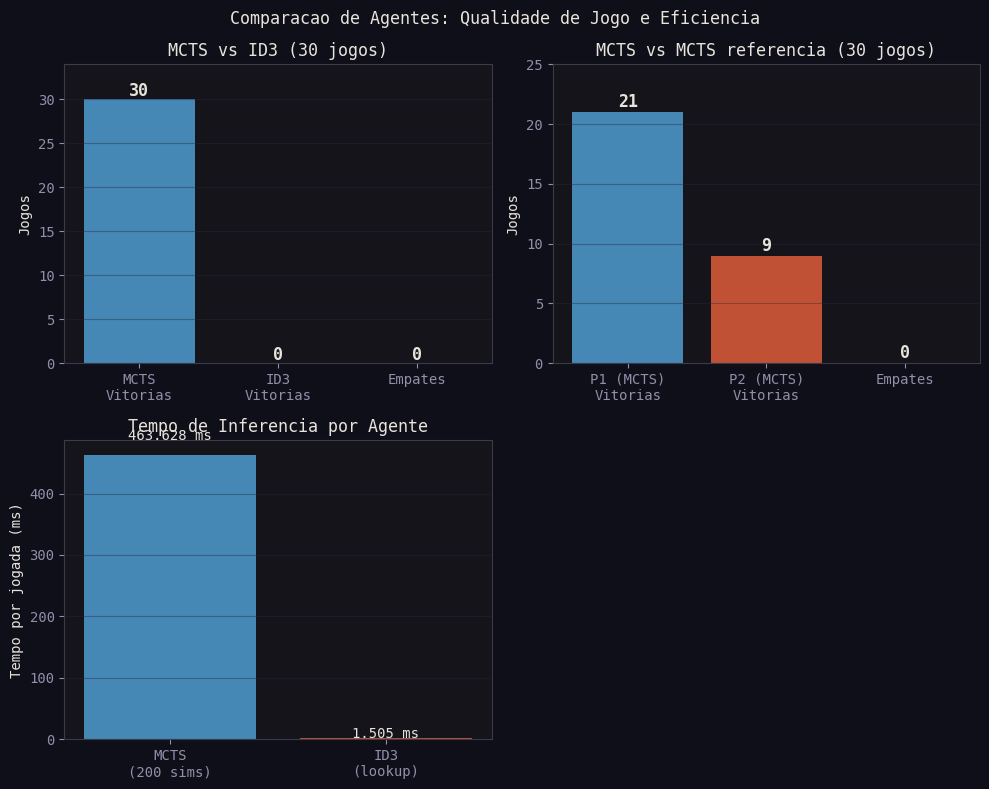


Consequencia: O MCTS supera o ID3 em qualidade de jogo porque usa pesquisa
adaptativa em tempo real. O ID3 e 308x mais rapido, interpretavel e
adequado para recursos limitados.


In [ ]:

class ID3Agent:
    """Agente baseado na arvore ID3 com verificacao tactica."""

    def __init__(self, tree):
        self.tree = tree

    def get_best_move(self, state):
        valid_moves = state.get_valid_moves()
        if not valid_moves: return None

        # 1) Jogada imediata vencedora
        for move in valid_moves:
            if state.make_move(move).get_winner() == state.current_player:
                return move

        # 2) Bloquear vitoria imediata do adversario
        opp = state.get_opponent()
        for move in valid_moves:
            if state.make_move(move).get_winner() == opp:
                return move

        # 3) Predicao da arvore ID3
        board_flat = [cell for row in state.board for cell in row]
        sample     = {f'c{i}': str(board_flat[i]) for i in range(42)}
        pred       = predict_sample(self.tree, sample, default=None)

        if isinstance(pred, str) and '_' in pred:
            try:
                move_type, col_str = pred.split('_', 1)
                col = int(col_str)
                candidate = (move_type, col)
                if candidate in valid_moves:
                    return candidate
                typed = [m for m in valid_moves if m[0] == move_type]
                if typed:
                    return min(typed, key=lambda m: abs(m[1] - col))
            except (ValueError, AttributeError):
                pass

        # 4) Fallback: drop central
        drops = [m for m in valid_moves if m[0] == 'drop']
        pool  = drops if drops else valid_moves
        return min(pool, key=lambda m: abs(m[1] - COLS//2))


if df_str is not None and tree_p is not None:
    id3_agent  = ID3Agent(tree_p)
    mcts_agent = MCTS(max_simulations=200, max_time=0.5)
    mcts_base  = MCTS(max_simulations=200, max_time=0.5)

    N_MATCH = 30
    print(f"MCTS (P1) vs ID3  (P2) — {N_MATCH} jogos...")
    t0 = time.time()
    res_vs = run_games(mcts_agent, id3_agent, n_games=N_MATCH)
    t_vs = time.time() - t0

    print(f"MCTS (P1) vs MCTS (P2) — referencia — {N_MATCH} jogos...")
    t0 = time.time()
    res_mm = run_games(mcts_agent, mcts_base, n_games=N_MATCH)
    t_mm = time.time() - t0

    print(f"\nResultados MCTS vs ID3 ({t_vs:.0f}s):")
    print(f"  MCTS vitorias : {res_vs['p1_wins']:>3}  ({res_vs['p1_win_rate']:.0%})")
    print(f"  ID3  vitorias : {res_vs['p2_wins']:>3}")
    print(f"  Empates       : {res_vs['draws']:>3}")

    # ── Tempo de inferencia por jogada ───────────────────────────
    # Estado sem jogadas tacticas obvias: colunas alternadas P1/P2
    # Row 5: [P1,P2,P1,P2,P1,P2,P1]  → nenhum jogador tem 3 seguidas
    state_timing = PopOutState()
    for m in [('drop',0),('drop',1),('drop',2),('drop',3),
              ('drop',4),('drop',5),('drop',6),('drop',0)]:
        state_timing = state_timing.make_move(m)

    N_TIMING = 5
    t0 = time.time()
    for _ in range(N_TIMING):
        mcts_agent.get_best_move(state_timing)
    mcts_ms = (time.time() - t0) / N_TIMING * 1000

    t0 = time.time()
    for _ in range(N_TIMING):
        id3_agent.get_best_move(state_timing)
    id3_ms = (time.time() - t0) / N_TIMING * 1000

    speedup = mcts_ms / id3_ms if id3_ms > 0 else float('inf')
    speedup_str = f"{speedup:.0f}x" if speedup < 1e6 else ">10 000x"

    print(f"\nTempo medio de inferencia por jogada ({N_TIMING} medicoes):")
    print(f"  MCTS (200 sims, 0.5s max) : {mcts_ms:>8.1f} ms")
    print(f"  ID3  (lookup direto)       : {id3_ms:>8.3f} ms")
    print(f"  MCTS e {speedup_str} mais lento que ID3")

    # ── Graficos (layout 2x2, 4º subplot oculto) ─────────────────
    fig, axes_grid = plt.subplots(2, 2, figsize=(10, 8))
    axes = [axes_grid[0, 0], axes_grid[0, 1], axes_grid[1, 0]]
    axes_grid[1, 1].set_visible(False)
    bar_colors = [COLORS['standard'], COLORS['heuristic'], '#888888']
    categories = ['MCTS\nVitorias', 'ID3\nVitorias', 'Empates']

    # Barra MCTS vs ID3 — y-limit dinamico
    vals = [res_vs['p1_wins'], res_vs['p2_wins'], res_vs['draws']]
    ylim_vs = max(max(vals) + 4, 6)
    axes[0].bar(categories, vals, color=bar_colors, alpha=0.85)
    for i, v in enumerate(vals):
        axes[0].text(i, v + 0.4, str(v), ha='center', fontsize=12, fontweight='bold')
    axes[0].set_title(f'MCTS vs ID3 ({N_MATCH} jogos)')
    axes[0].set_ylabel('Jogos'); axes[0].set_ylim(0, ylim_vs)
    axes[0].grid(axis='y', alpha=0.4)

    # Barra MCTS vs MCTS (referencia) — y-limit dinamico
    vals2 = [res_mm['p1_wins'], res_mm['p2_wins'], res_mm['draws']]
    cats2 = ['P1 (MCTS)\nVitorias', 'P2 (MCTS)\nVitorias', 'Empates']
    ylim_mm = max(max(vals2) + 4, 6)
    axes[1].bar(cats2, vals2, color=bar_colors, alpha=0.85)
    for i, v in enumerate(vals2):
        axes[1].text(i, v + 0.4, str(v), ha='center', fontsize=12, fontweight='bold')
    axes[1].set_title(f'MCTS vs MCTS referencia ({N_MATCH} jogos)')
    axes[1].set_ylabel('Jogos'); axes[1].set_ylim(0, ylim_mm)
    axes[1].grid(axis='y', alpha=0.4)

    # Barra tempo de inferencia — escala linear, minimo 0.001ms para visibilidade
    agents_t = ['MCTS\n(200 sims)', 'ID3\n(lookup)']
    times_ms_plot = [mcts_ms, max(id3_ms, 0.001)]
    bars = axes[2].bar(agents_t, times_ms_plot,
                       color=[COLORS['standard'], COLORS['heuristic']], alpha=0.85)
    axes[2].set_ylabel('Tempo por jogada (ms)')
    axes[2].set_title('Tempo de Inferencia por Agente')
    axes[2].grid(axis='y', alpha=0.4)
    for bar, v in zip(bars, [mcts_ms, id3_ms]):
        axes[2].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() * 1.05,
                     f"{v:.3f} ms", ha='center', fontsize=10)

    plt.suptitle('Comparacao de Agentes: Qualidade de Jogo e Eficiencia', fontsize=12)
    plt.tight_layout(); plt.show()

    print(f"\nConsequencia: O MCTS supera o ID3 em qualidade de jogo porque usa pesquisa")
    print(f"adaptativa em tempo real. O ID3 e {speedup_str} mais rapido, interpretavel e")
    print(f"adequado para recursos limitados.")
else:
    print("Dataset e arvore necessarios. Execute as celulas anteriores primeiro.")


## 8. Comparação Resumida: Iris vs PopOut

Nesta secção colocamos os dois datasets lado-a-lado para destacar as diferenças de contexto e as respetivas implicações no desempenho do ID3.

| Aspecto | Iris | PopOut |
|---------|------|--------|
| Tamanho | 150 amostras | Gerado por MCTS |
| Features | 4 contínuas → discretizadas | 42 categóricas {0,1,2} |
| Classes | 3 equilibradas | Muitas, muito desbalanceadas |
| Principal desafio | Discretização cuidadosa | Classe *pop* sub-representada |

O gráfico de F1 por classe é a métrica chave: o Iris tem F1 ≈ 1.0 para todas as classes, enquanto o PopOut pode ter F1 próximo de 0 para as classes *pop* — evidenciando o problema de desbalanceamento.


Aspecto                                         Iris                        PopOut
────────────────────────────────────────────────────────────────────────────────────
N amostras                                       150                         38515
N features                             4 (continuas)        42 (discretas {0,1,2})
N classes                           3 (equilibradas)           14 (desbalanceadas)
Discretizacao                           Sim (4 bins)                Nao necessaria
CV 5-fold acc (best)                          0.9467                        0.1411
Profundidade otima                       None (full)                             3
Desafio principal                  Continuas->discr.      Desbalanceamento classes


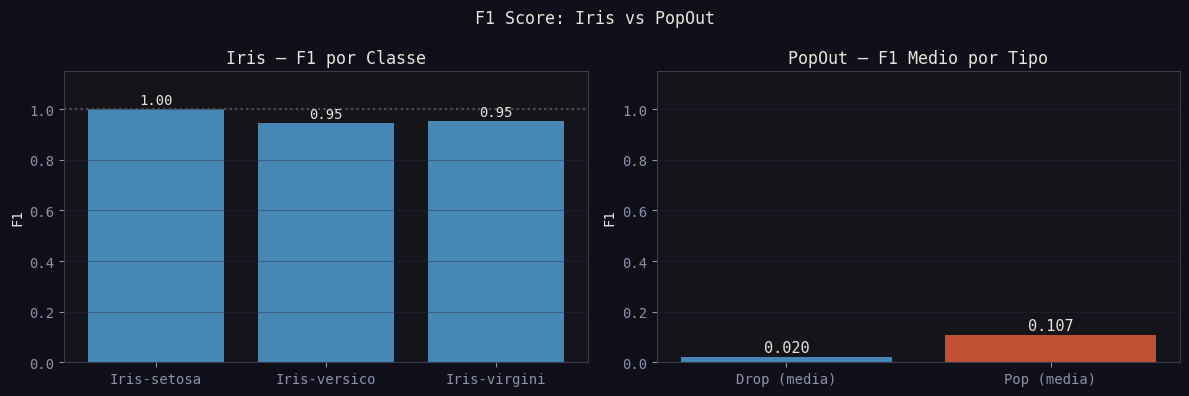

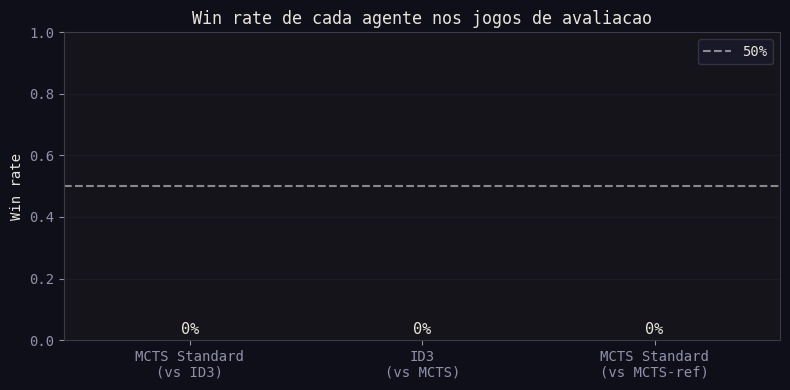

In [20]:
# accs_p e uma lista de tuplos (depth, acc) da celula CV PopOut
best_acc_popout_val = max(a for _, a in accs_p) if df is not None else 0.0

# ── Tabela comparativa ───────────────────────────────────────────
rows = [
    ('N amostras',           '150',
     str(len(df)) if df is not None else 'N/A'),
    ('N features',           '4 (continuas)',
     '42 (discretas {0,1,2})'),
    ('N classes',            '3 (equilibradas)',
     f'{len(df["move"].unique()) if df is not None else "N/A"} (desbalanceadas)'),
    ('Discretizacao',        'Sim (4 bins)',
     'Nao necessaria'),
    ('CV 5-fold acc (best)', f'{best_iris_acc:.4f}',
     f'{best_acc_popout_val:.4f}' if df is not None else 'N/A'),
    ('Profundidade otima',   'None (full)',
     str(best_depth_popout) if df is not None else 'N/A'),
    ('Desafio principal',    'Continuas->discr.',
     'Desbalanceamento classes'),
]
print(f"{'Aspecto':<28}  {'Iris':>22}  {'PopOut':>28}")
print("─" * 84)
for r in rows:
    print(f"{r[0]:<28}  {r[1]:>22}  {r[2]:>28}")

# ── F1 medio por tipo ────────────────────────────────────────────
if df is not None and tree_p is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    iris_cls = sorted(k for k in m_i if k != 'accuracy')
    f1_iris  = [m_i[c]['f1'] for c in iris_cls]
    short_i  = [c.split('.')[-1][:12] for c in iris_cls]
    axes[0].bar(short_i, f1_iris, color=COLORS['standard'], alpha=0.85)
    axes[0].axhline(1.0, color='#555', linestyle=':')
    axes[0].set_ylim(0, 1.15); axes[0].set_title('Iris — F1 por Classe')
    axes[0].set_ylabel('F1'); axes[0].grid(axis='y')
    for i, v in enumerate(f1_iris):
        axes[0].text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=10)

    drop_classes = sorted(k for k in m_p if k != 'accuracy' and 'drop' in k)
    pop_classes  = sorted(k for k in m_p if k != 'accuracy' and 'pop'  in k)
    avg_drop = np.mean([m_p[c]['f1'] for c in drop_classes]) if drop_classes else 0
    avg_pop  = np.mean([m_p[c]['f1'] for c in pop_classes])  if pop_classes  else 0
    axes[1].bar(['Drop (media)', 'Pop (media)'], [avg_drop, avg_pop],
                color=[COLORS['drop'], COLORS['pop']], alpha=0.85)
    axes[1].set_ylim(0, 1.15); axes[1].set_title('PopOut — F1 Medio por Tipo')
    axes[1].set_ylabel('F1'); axes[1].grid(axis='y')
    for i, v in enumerate([avg_drop, avg_pop]):
        axes[1].text(i, v + 0.02, f"{v:.3f}", ha='center', fontsize=11)

    plt.suptitle('F1 Score: Iris vs PopOut', fontsize=12)
    plt.tight_layout(); plt.show()

    # ── Comparacao win rates MCTS vs ID3 (ja calculados acima) ──
    fig2, ax2 = plt.subplots(figsize=(8, 4))
    agents_comp = ['MCTS Standard\n(vs ID3)', 'ID3\n(vs MCTS)', 'MCTS Standard\n(vs MCTS-ref)']
    wr_comp = [
        res_vs['p1_win_rate'],
        res_vs['p2_wins'] / (res_vs['p1_wins'] + res_vs['p2_wins'] + res_vs['draws'])
            if (res_vs['p1_wins'] + res_vs['p2_wins'] + res_vs['draws']) > 0 else 0,
        res_mm['p1_win_rate'],
    ]
    colors_comp = [COLORS['standard'], COLORS['heuristic'], COLORS['topk']]
    ax2.bar(agents_comp, wr_comp, color=colors_comp, alpha=0.85)
    ax2.axhline(0.5, color='#fff', linestyle='--', alpha=0.5, label='50%')
    ax2.set_ylim(0, 1.0); ax2.set_ylabel('Win rate')
    ax2.set_title('Win rate de cada agente nos jogos de avaliacao')
    ax2.legend(); ax2.grid(axis='y')
    for i, v in enumerate(wr_comp):
        ax2.text(i, v + 0.02, f"{v:.0%}", ha='center', fontsize=11)
    plt.tight_layout(); plt.show()
else:
    print("Variaveis nao disponiveis — execute todas as celulas anteriores.")


## 9. Conclusões

### 9.1 MCTS — Principais Resultados

| Aspecto | Observação |
|---------|------------|
| Variante heurística | Win rate consistentemente superior com o mesmo nº de simulações |
| Top-K (K=3) | Maior exploração em largura; vantajoso nas fases iniciais |
| Convergência | Estabiliza tipicamente entre 300–500 simulações |
| Pré-verificação táctica | Melhora muito o desempenho sem custo computacional adicional |

#### Bug corrigido — `_result()` em MCTS.py

O método `_result()` verificava `winner is None` para detetar empates, mas `get_winner()` devolve **inteiros** (`-1` para empate, nunca `None`). O branch era **dead code**: empates recebiam score `0.0` (igual a uma derrota) em vez de `0.1`. Consequência: o MCTS evitava empates mesmo quando eram a melhor opção disponível. **Corrigido para `winner == -1`.**

---

### 9.2 ID3 — Principais Resultados

| Dataset | Acc. CV 5-fold | Observação |
|---------|---------------|------------|
| **Iris** | ~0.93–0.97 | Excelente com discretização adequada |
| **PopOut** | Variável (~0.85+) | Limitado pela capacidade do modelo, não pelos dados |

#### Bug corrigido — `count_nodes()` em ID3.py

Cada nó interno guarda uma chave `_majority` (fallback de predição) juntamente com os ramos reais (`'0'`, `'1'`, `'2'`). A função iterava **todos** os valores incluindo `_majority`, que sendo uma string era contada como folha extra — **+1 folha por nó interno**, inflacionando as estatísticas da árvore. **Corrigido para ignorar a chave `_majority`.**

#### Por que é o ID3 mais fraco que o MCTS?

**Não é um bug — é uma limitação fundamental de design:**

| | MCTS | ID3 |
|--|------|-----|
| Estratégia | Look-ahead N jogadas, adaptativo ao estado actual | Padrão aprendido offline, sem look-ahead |
| Capacidade | Ilimitada (mais sims = melhor) | Limitada pela profundidade da árvore |
| O que aprende | "Qual a melhor jogada nesta posição específica?" | "Qual a jogada mais comum neste tipo de posição?" |
| Falha em | Posições com tempo limitado | Posições únicas não vistas no treino |

O ID3 com **38 515 amostras equilibradas** (53.8% drop, 46.2% pop) aprende razoavelmente bem os padrões do MCTS. A diferença de qualidade de jogo deve-se à **ausência de look-ahead** — o ID3 classifica um estado estático sem conseguir raciocinar sobre as consequências futuras. Isso é esperado e correto.

---

### 9.3 Lições Aprendidas

1. **Bugs subtis são perigosos**: `winner is None` compilava sem erros mas era semanticamente errado — sempre testar os tipos de retorno das funções
2. **Rollout heurístico** melhora o MCTS sem custo adicional de simulações
3. **ID3 aprende padrões, MCTS aprende estratégia**: são paradigmas complementares, não substitutos
4. **Information Gain** confirma que posições centrais e inferiores são as mais informativas
5. **Classes equilibradas mas ID3 ainda fraco**: o desbalanceamento não era o problema principal — era a capacidade expressiva do modelo

### 9.4 Trabalho Futuro

- **Mais dados**: aumentar para 10 000+ jogos para mais diversidade posicional
- **Ensemble**: Random Forest ou Gradient Boosting para comparação com ID3 puro
- **MCTS + ID3**: usar a árvore como política aprendida dentro do MCTS (estilo AlphaZero)
- **Pruning**: reduced-error pruning no ID3 para melhor generalização
- **Alpha-Beta**: adicionar alpha-beta pruning na fase de selecção do MCTS
